TEXT TO TEXT

In [2]:
import os
OPENAI_API_KEY = os.getenv ("OPENAI_API_KEY")  # This will return None if the environment variable is not set
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [29]:
from langchain_openai import ChatOpenAI

e:\AI-Learning\Gen-AI\KN-CRS\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
llm = ChatOpenAI(model="gpt-5-nano")

In [4]:
message = llm.invoke("What is the capital of India?")

In [5]:
message.content

'New Delhi. It’s the capital city and the seat of the Government of India, located in the National Capital Territory of Delhi.'

TEXT TO IMAGE

In [6]:
llm =ChatOpenAI(model = "gpt-5.4-mini")

In [7]:
kwargs = {"type": "image_generation", "quality": "low"}

In [8]:
llm_with_tools =llm.bind_tools([kwargs])

In [9]:
ai_message = llm_with_tools.invoke("Draw a picture of a cute fuzzy cat with an umbrella")  

In [11]:
ai_message

AIMessage(content=[{'id': 'ig_0b9677b56711ef52006a15933fc78081969978b6d393eac57c', 'result': '...', 'status': 'completed', 'type': 'image_generation_call', 'action': 'generate', 'background': 'opaque', 'output_format': 'png', 'quality': 'low', 'revised_prompt': "A cute fuzzy cat holding an umbrella, whimsical and charming, soft fluffy fur, big expressive eyes, pastel colors, gentle lighting, simple clean background, adorable children's book illustration style", 'size': '1199x1312'}, {'type': 'text', 'text': '', 'annotations': [], 'id': 'msg_0b9677b56711ef52006a159359e44481968e43755d35a91a57', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_0b9677b56711ef52006a15933ea640819685b0915d98708be8', 'created_at': 1779798847.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0b9677b56711ef52006a15933ea640819685

In [19]:
import base64
from IPython.display import Image

In [29]:
image = next(
    item for item in ai_message.content_blocks if item["type"] == "image"
)

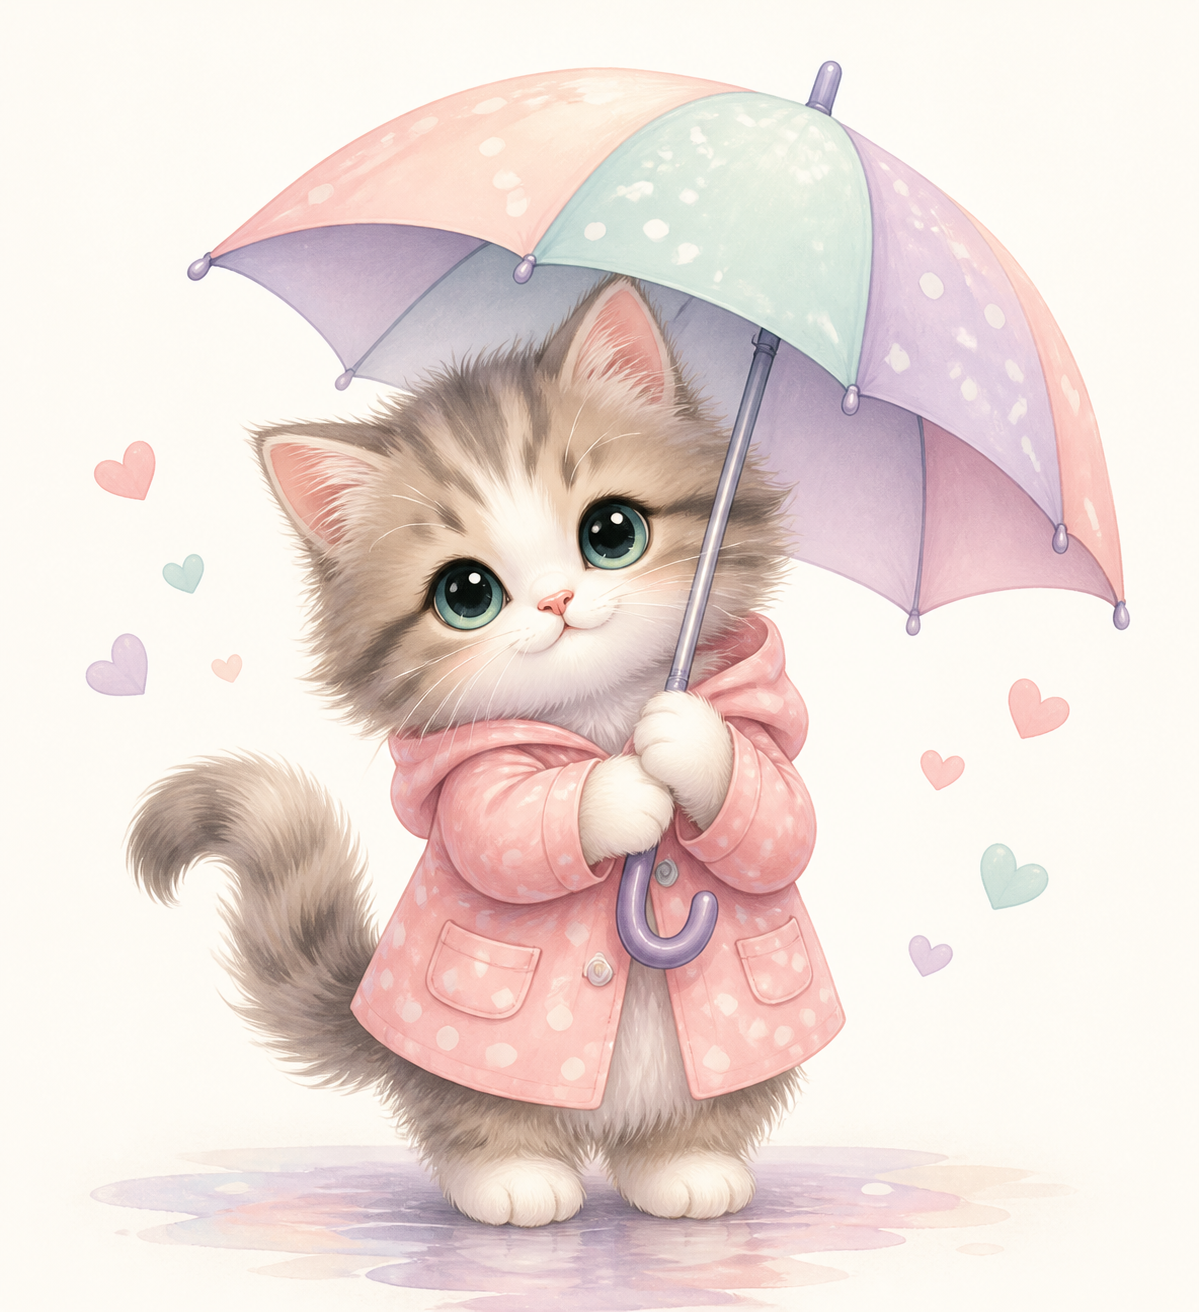

In [30]:
Image(base64.b64decode(image["base64"]), width=200)

IMAGE TO TEXT

In [3]:
llm =ChatOpenAI(model = "gpt-4o-mini")

In [4]:
def encode_image_to_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [7]:
base64_image = encode_image_to_base64("./dogs.png")

In [21]:
from langchain_core.messages import HumanMessage

In [10]:
message = HumanMessage(
    content=[
        {"type": "text", "text": "What is in this image?"},
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{base64_image}"
            },
        },
    ]
)

HumanMessage(content=[{'type': 'text', 'text': 'What is in this image?'}, {'type': 'image_url', 'image_url': {'url': ''}}], additional_kwargs={}, response_metadata={})
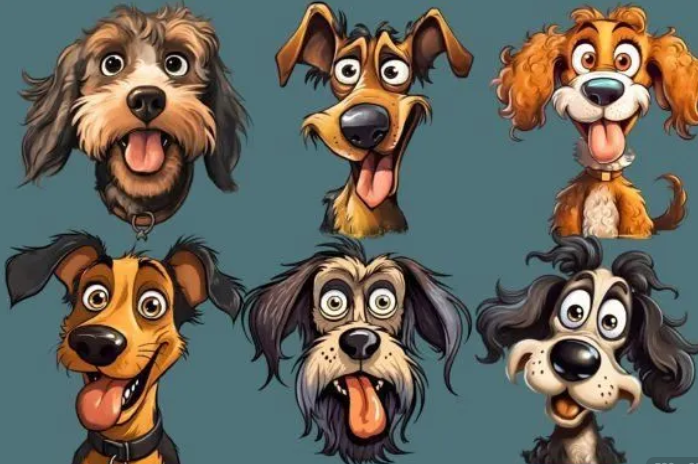

In [11]:
message

In [12]:
response = llm.invoke([message])

In [13]:
print(response.content)

The image features a collage of six cartoon-style dogs, each with distinctive and playful expressions. The dogs are drawn with exaggerated features, such as large eyes and big smiles, giving them a whimsical and joyful appearance. They are depicted in various poses against a solid background.


HUGGINGFACE TEXT TO TEXT


In [1]:
import os
HUGGINGFACEHUB_API_TOKEN = os.getenv ("HUGGINGFACEHUB_API_TOKEN")  # This will return None if the environment variable is not set
if HUGGINGFACEHUB_API_TOKEN:
    os.environ["HUGGINGFACEHUB_API_TOKEN"] = HUGGINGFACEHUB_API_TOKEN

In [3]:
from langchain_huggingface import HuggingFaceEndpoint

e:\AI-Learning\Gen-AI\KN-CRS\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1-0528",
    # repo_id="deepseek-ai/DeepSeek-V4-Pro",
    task="text-generation",
    max_new_tokens=512
)

In [5]:
from langchain_huggingface import ChatHuggingFace

chat_model = ChatHuggingFace(llm=llm)

In [14]:
ai_message = chat_model.invoke("Who is subhas chandra bose??") 

In [13]:
ai_message

AIMessage(content='<think>\nOkay, the user is asking about Srinjay Kapri and whether he can be an AI engineer. First, I need to recall who Srinjay Kapri is. From what I remember, he\'s an Indian actor known for his roles in TV shows like "Sadda Haq" and "Yeh Hai Mohabbatein." But the user is asking if he can be an AI engineer, which is a career switch. \n\nHmm, the user might be confused. Maybe they heard the name in a different context, or there\'s another Srinjay Kapri in tech? But based on available info, the actor is the most prominent. The question seems to mix two different fields—acting and AI engineering. \n\nThe user\'s main query is whether Srinjay can become an AI engineer. They might be curious about career changes or the feasibility of switching industries. Alternatively, they might have encountered someone with the same name in tech and are trying to verify. \n\nI should clarify that as an actor, Srinjay doesn\'t have a known background in AI. But it\'s possible for anyon

AUDIO TO TEXT



In [1]:
import base64
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

e:\AI-Learning\Gen-AI\KN-CRS\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def encode_audio(audio_path):
    with open(audio_path, "rb") as audio_file:
        return base64.b64encode(audio_file.read()).decode("utf-8")

In [3]:
base64_audio = encode_audio("./audio.mp3")

In [4]:
import os
GOOGLE_API_KEY = os.getenv ("GOOGLE_API_KEY")  # This will return None if the environment variable is not set
if GOOGLE_API_KEY:
    os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

In [17]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY
)

In [18]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Transcribe this audio into English text."
        },
        {
            "type": "media",
            "mime_type": "audio/mp3",
            "data": base64_audio
        }
    ]
)

In [19]:
response = llm.invoke([message])

In [20]:
response.content

'Hello students. Today we are learning about multimodal AI, one of the most exciting areas in artificial intelligence, where models can understand and generate multiple types of data such as text, images, audio, and video, enabling powerful applications like image captioning, speech recognition, text to image generation, AI voice assistants, visual question answering, and intelligent agentic systems that can interact with the world in a much more human-like way.'